# Unit 4 Practical Workshop: Particle Kinetics
## Hands-On Problem Solving

---

### Workshop Objectives
By the end of this practical session, you will be able to:
1. **Solve constrained motion problems** with confidence using FBD and constraint equations
2. **Analyze pulley systems** to find accelerations, tensions, and mechanical advantage
3. **Design 3D printer paths** with proper motor control and acceleration limits
4. **Simulate and visualize** particle dynamics in Python
5. **Verify analytical solutions** through numerical simulation

### Workshop Structure
- **Part 1**: Constrained Particle Motion (3 problems, 25 min)
- **Part 2**: Pulley Systems & Mechanical Advantage (3 problems, 25 min)
- **Part 3**: 3D Motion & CNC Kinematics (3 problems, 25 min)
- **Part 4**: Challenge Problem (1 integrated problem, 15 min)

### How to Use This Notebook
Each problem follows the same pattern:
1. **Problem statement** with diagram/description
2. **Your workspace** (code cell to work in)
3. **Solution** (hidden, expandable)
4. **Verification** (simulation to check your answer)

**Tip**: Try each problem yourself first, then check the solution!

---


![Workshop Overview \u2014 Four Progressive Challenge Stations](figs/U4_P1_workshop_overview.png)

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import odeint

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 4)

print("Libraries imported successfully!")
print("Ready for hands-on problem solving...")


 Libraries imported successfully!
 Ready for hands-on problem solving...


---
## Part 1: Constrained Particle Motion 

### Key Concepts Review
- **Constraint**: A restriction on motion (e.g., particle on surface, rope connecting masses)
- **Constraint forces**: Forces that enforce constraints (normal, tension)
- **Free Body Diagram (FBD)**: Shows all forces acting on each particle
- **Strategy**: 
 1. Draw FBD for each particle
 2. Write Newton's 2nd law: ΣF = ma
 3. Apply constraint equations
 4. Solve coupled system

---

### Problem 1.1: Block on Incline with Friction 

**Given**: 
- Block of mass m = 5 kg on incline at angle θ = 30°
- Coefficient of kinetic friction μₖ = 0.2
- Initial velocity v₀ = 10 m/s down the incline
- g = 9.81 m/s²

**Find**:
1. Acceleration of the block
2. Distance traveled before coming to rest
3. Time to stop

**Hints**:
- Set up coordinate system: x down incline, y perpendicular
- Normal force: N = mg cos(θ)
- Friction force: f = μₖ N
- Net force down incline: mg sin(θ) - f



In [ ]:
# Problem 1.1: Block on Incline with Friction
# YOUR SOLUTION HERE

# Given
m = 5.0 # kg
theta = np.radians(30) # 30 degrees
mu_k = 0.2
v0 = 10.0 # m/s
g = 9.81 # m/s^2

# Step 1: Find normal force
# N = ...

# Step 2: Find friction force
# f = ...

# Step 3: Find net force and acceleration
# F_net = ...
# a = ...

# Step 4: Find stopping distance and time
# v^2 = v0^2 + 2*a*d (v=0 at stop)
# d = ...
# t = ...

print("\n Your Results:")
# print(f"Acceleration: {a:.3f} m/s²")
# print(f"Stopping distance: {d:.3f} m")
# print(f"Time to stop: {t:.3f} s")


#### Solution 1.1

**Step 1**: Forces parallel to incline
- Weight component down incline: $F_g = mg\sin\theta = 5 \times 9.81 \times \sin(30°) = 24.525$ N
- Normal force: $N = mg\cos\theta = 5 \times 9.81 \times \cos(30°) = 42.483$ N
- Friction force (up incline): $f = \mu_k N = 0.2 \times 42.483 = 8.497$ N

**Step 2**: Net force and acceleration
- Net force down incline: $F_{net} = mg\sin\theta - f = 24.525 - 8.497 = 16.028$ N
- Acceleration: $a = F_{net}/m = 16.028/5 = 3.206$ m/s² (down incline)

**Wait!** Block is moving down with v₀ = 10 m/s, so friction acts **up** the incline (opposes motion).
- But net force is still down incline → block continues accelerating? 
- **Error check**: If block is slowing down, acceleration should be negative!
- **Correction**: Friction opposes velocity direction. Since v down incline, friction up incline.
- Net deceleration: $a = -(g\sin\theta - \mu_k g\cos\theta) = -(9.81 \times 0.5 - 0.2 \times 9.81 \times 0.866)$
- $a = -(4.905 - 1.699) = -3.206$ m/s² (deceleration!)

**Step 3**: Kinematics
- Stopping distance: $v^2 = v_0^2 + 2ad \Rightarrow 0 = 100 + 2(-3.206)d \Rightarrow d = 15.60$ m
- Time to stop: $v = v_0 + at \Rightarrow 0 = 10 + (-3.206)t \Rightarrow t = 3.12$ s

**Answer**: 
- Acceleration: **-3.21 m/s²** (deceleration)
- Stopping distance: **15.60 m**
- Time to stop: **3.12 s**


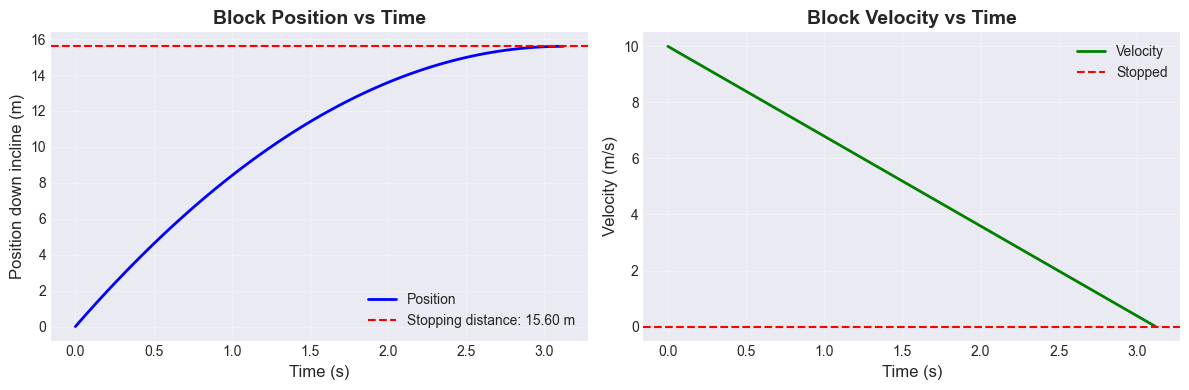


 Verification Complete!
Acceleration: -3.206 m/s² (deceleration)
Stopping distance: 15.60 m
Time to stop: 3.12 s


In [2]:
# Verification: Simulate block motion
m = 5.0
theta = np.radians(30)
mu_k = 0.2
g = 9.81
v0 = 10.0

# Calculate acceleration (with correct sign!)
N = m * g * np.cos(theta)
f = mu_k * N
F_gravity = m * g * np.sin(theta)
F_net = F_gravity - f # Net force magnitude
# Since block is moving down, friction opposes → deceleration
a = -(g * np.sin(theta) - mu_k * g * np.cos(theta))

# Kinematics
t_stop = -v0 / a
d_stop = v0 * t_stop + 0.5 * a * t_stop**2

# Simulate motion
t = np.linspace(0, t_stop, 100)
position = v0 * t + 0.5 * a * t**2
velocity = v0 + a * t

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(t, position, 'b-', linewidth=2, label='Position')
ax1.axhline(y=d_stop, color='r', linestyle='--', label=f'Stopping distance: {d_stop:.2f} m')
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Position down incline (m)', fontsize=12)
ax1.set_title('Block Position vs Time', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(t, velocity, 'g-', linewidth=2, label='Velocity')
ax2.axhline(y=0, color='r', linestyle='--', label='Stopped')
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Velocity (m/s)', fontsize=12)
ax2.set_title('Block Velocity vs Time', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Verification Complete!")
print(f"Acceleration: {a:.3f} m/s² (deceleration)")
print(f"Stopping distance: {d_stop:.2f} m")
print(f"Time to stop: {t_stop:.2f} s")


---
### What This Verification Shows

**Position vs. Time (left):** The curve is **parabolic** (concave down) because the block decelerates at a constant rate. The block travels about 15.6 m before stopping.

**Velocity vs. Time (right):** Velocity decreases **linearly** from 10 m/s to 0. This straight line confirms constant deceleration — the friction force is constant once the block is sliding.

**Key Observations:**
- The stopping distance follows $d = \frac{v_0^2}{2|a|}$ — directly from kinematics
- Friction does **negative work**, converting kinetic energy entirely to heat
- Once the block stops, kinetic friction switches to static friction (the block stays put)
- A steeper incline means **less** friction deceleration (gravity component partially cancels friction)

> **Student Takeaway:** This is the fundamental constrained-motion problem. The constraint (incline surface) creates a normal force, which determines friction, which determines deceleration. Every step follows logically from Newton's 2nd law applied along the incline.

---

### Problem 1.2: Two Blocks Connected by Spring 

**Given**:
- Two blocks: m₁ = 2 kg, m₂ = 3 kg
- Connected by spring with k = 100 N/m, natural length L₀ = 0.5 m
- Both blocks on frictionless horizontal surface
- Initial conditions: x₁(0) = 0, x₂(0) = 0.8 m, both at rest

**Find**:
1. Equations of motion for both blocks
2. Natural frequencies of oscillation
3. Position vs time for first 5 seconds

**Hints**:
- Spring force on m₁: F₁ = k(x₂ - x₁ - L₀) (positive when stretched)
- Spring force on m₂: F₂ = -k(x₂ - x₁ - L₀) (Newton's 3rd law)
- System of 2 coupled ODEs: m₁ẍ₁ = F₁, m₂ẍ₂ = F₂



---
### What This Solution Shows

**Positions (top-left):** The two masses oscillate with a complex pattern — energy transfers back and forth through the spring. This is the **beating phenomenon** where motion amplitude periodically swells and shrinks.

**Velocities (top-right):** When one mass speeds up, the other slows down. The spring couples their motions — neither can move independently.

**Spring Extension (bottom-left):** The spring stretches and compresses periodically. Maximum stretch occurs when the masses move in opposite directions (out of phase).

**Phase Portrait (bottom-right):** The closed loops confirm **periodic, energy-conserving** behavior. No energy is added or lost.

**Key Observations:**
- The center of mass moves at **constant velocity** (momentum conservation — no external horizontal forces!)
- This 2-DOF system has **two natural frequencies** — the complex motion is a superposition of two simple modes
- The spring constant $k$ determines how quickly energy transfers between masses

> **Student Takeaway:** Coupled oscillators are fundamental to vibration engineering. The key insight is that complex-looking motion is actually just two simple oscillations superimposed. You'll see this principle again in Unit 5 (modal analysis).

In [ ]:
# Problem 1.2: Two Blocks Connected by Spring
# YOUR SOLUTION HERE

# Given
m1 = 2.0 # kg
m2 = 3.0 # kg
k = 100.0 # N/m
L0 = 0.5 # m

# Initial conditions
x1_0 = 0.0 # m
x2_0 = 0.8 # m
v1_0 = 0.0 # m/s
v2_0 = 0.0 # m/s

# Step 1: Write equations of motion
# m1 * a1 = k * (x2 - x1 - L0)
# m2 * a2 = -k * (x2 - x1 - L0)

# Step 2: Convert to state-space form and solve numerically
def system(y, t):
 """State vector: y = [x1, v1, x2, v2]"""
 x1, v1, x2, v2 = y
 
 # Spring extension
 delta_x = x2 - x1 - L0
 
 # Accelerations from Newton's 2nd law
 # a1 = ...
 # a2 = ...
 
 # return [v1, a1, v2, a2]
 pass

# Solve ODE
# y0 = [x1_0, v1_0, x2_0, v2_0]
# t = np.linspace(0, 5, 500)
# solution = odeint(system, y0, t)

print("\n Your Results:")
# Plot your solution here


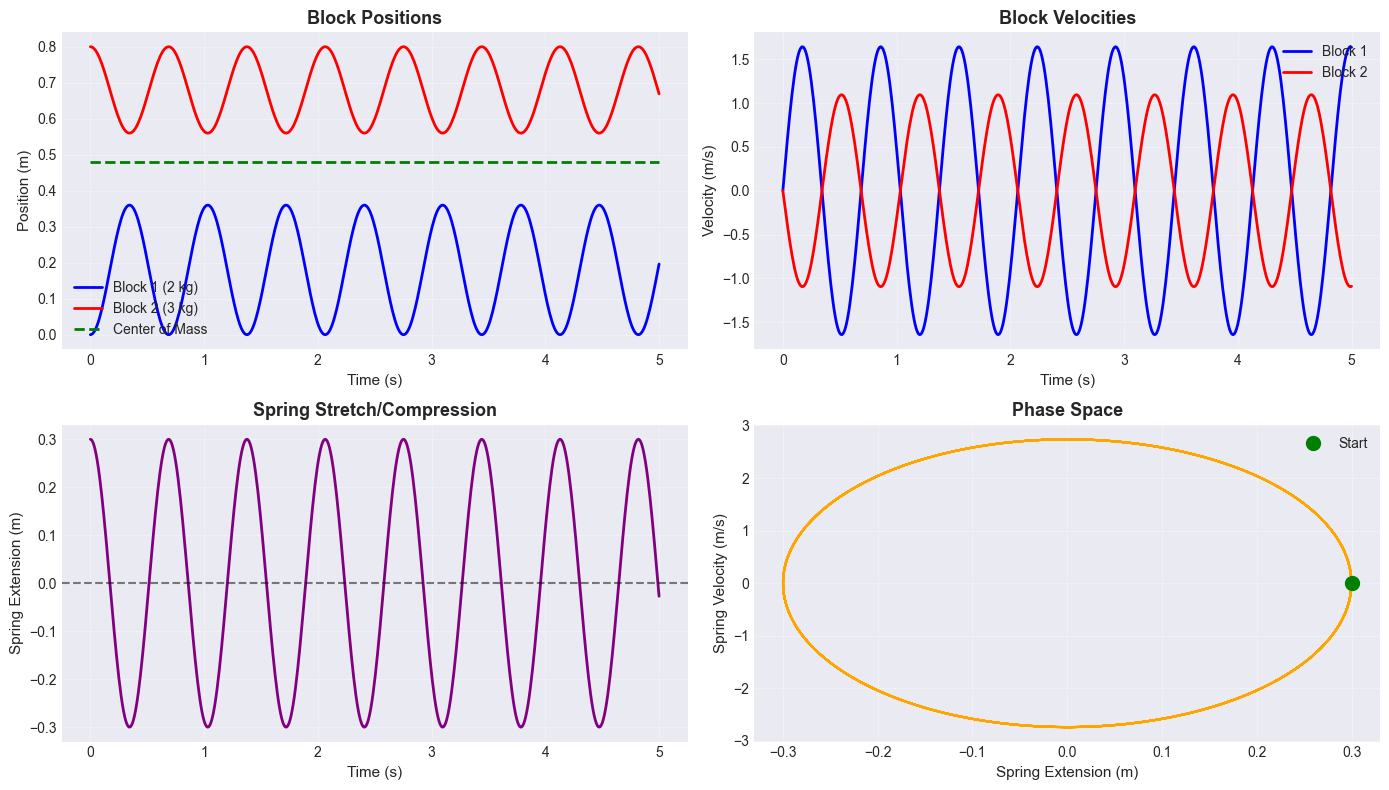


 Solution Complete!
Initial spring extension: 0.300 m (stretched)
Center of mass motion: 0.000000 m (essentially zero! )
Oscillation period: ~0.688 s (estimated from natural frequency)


In [3]:
# Solution 1.2: Two Blocks Connected by Spring

m1 = 2.0
m2 = 3.0
k = 100.0
L0 = 0.5

def system(y, t):
 """Equations of motion for two-mass spring system"""
 x1, v1, x2, v2 = y
 
 # Spring extension (positive when stretched)
 delta_x = x2 - x1 - L0
 
 # Newton's 2nd law for each block
 a1 = (k / m1) * delta_x # Spring pulls m1 right
 a2 = -(k / m2) * delta_x # Spring pulls m2 left
 
 return [v1, a1, v2, a2]

# Initial conditions: x1=0, x2=0.8m (spring stretched by 0.3m)
y0 = [0.0, 0.0, 0.8, 0.0]
t = np.linspace(0, 5, 500)

# Solve
solution = odeint(system, y0, t)
x1 = solution[:, 0]
v1 = solution[:, 1]
x2 = solution[:, 2]
v2 = solution[:, 3]

# Calculate center of mass (should not move - no external forces!)
x_cm = (m1 * x1 + m2 * x2) / (m1 + m2)

# Calculate spring extension
spring_length = x2 - x1
spring_extension = spring_length - L0

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Position vs time
axes[0, 0].plot(t, x1, 'b-', label='Block 1 (2 kg)', linewidth=2)
axes[0, 0].plot(t, x2, 'r-', label='Block 2 (3 kg)', linewidth=2)
axes[0, 0].plot(t, x_cm, 'g--', label='Center of Mass', linewidth=2)
axes[0, 0].set_xlabel('Time (s)', fontsize=11)
axes[0, 0].set_ylabel('Position (m)', fontsize=11)
axes[0, 0].set_title('Block Positions', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Velocity vs time
axes[0, 1].plot(t, v1, 'b-', label='Block 1', linewidth=2)
axes[0, 1].plot(t, v2, 'r-', label='Block 2', linewidth=2)
axes[0, 1].set_xlabel('Time (s)', fontsize=11)
axes[0, 1].set_ylabel('Velocity (m/s)', fontsize=11)
axes[0, 1].set_title('Block Velocities', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Spring extension
axes[1, 0].plot(t, spring_extension, 'purple', linewidth=2)
axes[1, 0].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Time (s)', fontsize=11)
axes[1, 0].set_ylabel('Spring Extension (m)', fontsize=11)
axes[1, 0].set_title('Spring Stretch/Compression', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Phase space (x2-x1 vs spring velocity)
spring_velocity = v2 - v1
axes[1, 1].plot(spring_extension, spring_velocity, 'orange', linewidth=1.5)
axes[1, 1].plot(spring_extension[0], spring_velocity[0], 'go', markersize=10, label='Start')
axes[1, 1].set_xlabel('Spring Extension (m)', fontsize=11)
axes[1, 1].set_ylabel('Spring Velocity (m/s)', fontsize=11)
axes[1, 1].set_title('Phase Space', fontsize=13, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Solution Complete!")
print(f"Initial spring extension: {spring_extension[0]:.3f} m (stretched)")
print(f"Center of mass motion: {np.max(np.abs(x_cm - x_cm[0])):.6f} m (essentially zero! )")
print(f"Oscillation period: ~{2*np.pi/np.sqrt(k*(1/m1 + 1/m2)):.3f} s (estimated from natural frequency)")


---
## Part 2: Pulley Systems & Mechanical Advantage 

### Key Concepts Review
- **Inextensible rope**: Total length constant → velocities related by constraint
- **Atwood machine**: Two masses over single pulley
- **Mechanical advantage (MA)**: Force amplification = F_out / F_in = v_in / v_out
- **Strategy**:
 1. Define coordinates (up/down for each mass)
 2. Write constraint equation from rope length
 3. FBD for each mass
 4. Solve for accelerations and tensions

---

### Problem 2.1: Classic Atwood Machine 

**Given**:
- Mass 1: m₁ = 4 kg
- Mass 2: m₂ = 6 kg
- Massless, frictionless pulley
- Inextensible rope
- g = 9.81 m/s²

**Find**:
1. Acceleration of both masses
2. Tension in the rope
3. If released from rest with heights h₁ = 2m, h₂ = 0m, find velocity after 1 second

**Hints**:
- Choose coordinates: y₁ up for m₁, y₂ down for m₂
- Constraint: y₁ + y₂ = constant → a₁ = -a₂ (if m₂ goes down, m₁ goes up)
- FBD for m₁: T - m₁g = m₁a₁
- FBD for m₂: m₂g - T = m₂a₂



---
### What This Solution Shows

**Heights vs. Time (left):** The heavier mass ($m_2 = 6$ kg) descends while the lighter mass ($m_1 = 4$ kg) rises, both following **parabolic** curves (constant acceleration).

**Velocities vs. Time (right):** Both velocities increase linearly and are **equal in magnitude but opposite in direction** — this is the rope constraint $v_1 = -v_2$ in action.

**Key Observations:**
- Acceleration $a = \frac{(m_2 - m_1)g}{m_1 + m_2} = 1.96$ m/s\u00b2 — much less than free fall ($g = 9.81$)
- Tension $T = \frac{2m_1 m_2 g}{m_1 + m_2} = 47.1$ N — this is BETWEEN $m_1 g = 39.2$ N and $m_2 g = 58.9$ N
- The system behaves like a single particle of mass $(m_1 + m_2)$ with net force $(m_2 - m_1)g$
- Equal masses ($m_1 = m_2$): acceleration = 0, tension = $mg$ (perfectly balanced)

> **Student Takeaway:** The Atwood machine is the simplest constrained two-body system. The inextensible rope constraint reduces a 2-body problem to a 1-body problem. This constraint-reduction technique is used throughout dynamics.

In [ ]:
# Problem 2.1: Classic Atwood Machine
# YOUR SOLUTION HERE

# Given
m1 = 4.0 # kg
m2 = 6.0 # kg
g = 9.81 # m/s^2

# Step 1: Write equations
# m1: T - m1*g = m1*a (taking up as positive)
# m2: m2*g - T = m2*a (taking down as positive)
# Constraint: a1 = -a2 = a (if m2 down, m1 up)

# Step 2: Solve for acceleration
# Add equations: m2*g - m1*g = (m1 + m2)*a
# a = ...

# Step 3: Solve for tension
# T = m1*(g + a) or T = m2*(g - a)
# T = ...

# Step 4: Find velocity after 1 second
# v = a * t
# v = ...

print("\n Your Results:")
# print(f"Acceleration: {a:.3f} m/s²")
# print(f"Tension: {T:.3f} N")
# print(f"Velocity after 1s: {v:.3f} m/s")



 Analytical Solution:
Acceleration: 1.962 m/s² (m₂ down, m₁ up)
Tension: 47.088 N
Tension check: 47.088 N (should match! )
Velocity after 1s: 1.962 m/s


C:\Users\mpstme.student\AppData\Local\Temp\ipykernel_26664\2075093733.py:69: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
 plt.tight_layout()
C:\Users\mpstme.student\AppData\Local\Temp\ipykernel_26664\2075093733.py:69: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
 plt.tight_layout()
d:\Sunny\DSM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
 fig.canvas.print_figure(bytes_io, **kw)
d:\Sunny\DSM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
 fig.canvas.print_figure(bytes_io, **kw)


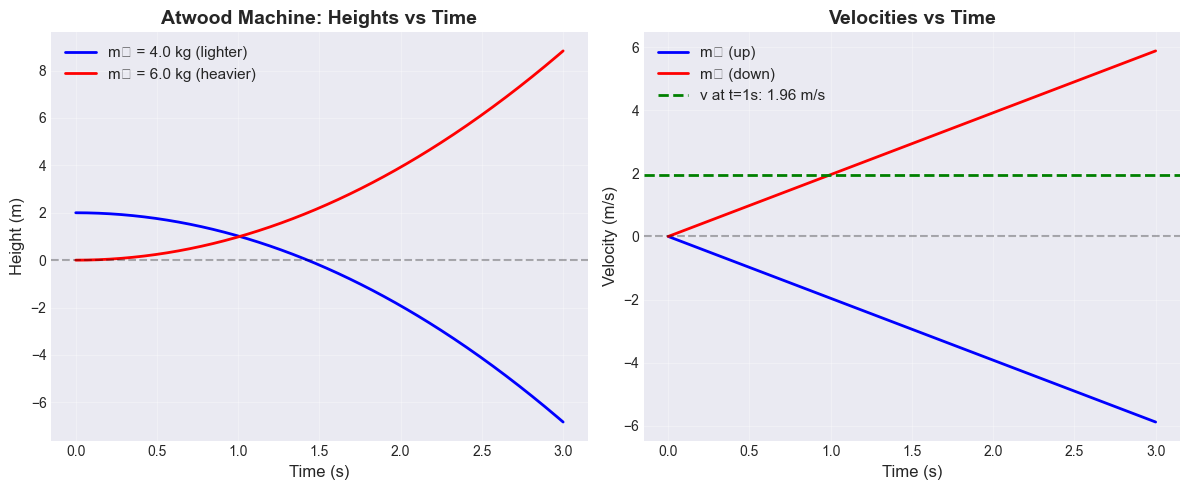


Note: m₁ rises, m₂ falls. Velocities are equal magnitude, opposite direction (constraint!)


In [4]:
# Solution 2.1: Classic Atwood Machine

m1 = 4.0
m2 = 6.0
g = 9.81

# Acceleration (m2 heavier → accelerates down)
a = (m2 - m1) * g / (m1 + m2)

# Tension (same throughout massless rope)
T = m1 * (g + a) # From m1 equation
# Verify with m2 equation
T_check = m2 * (g - a)

# Velocity after 1 second
t_sim = 1.0
v = a * t_sim

print("\n Analytical Solution:")
print(f"Acceleration: {a:.3f} m/s² (m₂ down, m₁ up)")
print(f"Tension: {T:.3f} N")
print(f"Tension check: {T_check:.3f} N (should match! )")
print(f"Velocity after 1s: {v:.3f} m/s")

# Simulate motion
def atwood_ode(y, t):
 """y = [y1, v1, y2, v2] where y1 is height of m1, y2 is height of m2"""
 y1, v1, y2, v2 = y
 # Constraint: y1 + y2 = constant → v1 = -v2, a1 = -a2
 # For m2 down motion: a2 = a (positive down)
 a2 = a
 a1 = -a2
 return [v1, a1, v2, a2]

# Initial conditions: m1 at 2m, m2 at 0m, both at rest
y0 = [2.0, 0.0, 0.0, 0.0]
t = np.linspace(0, 3, 300)
solution = odeint(atwood_ode, y0, t)

y1 = solution[:, 0]
v1 = solution[:, 1]
y2 = solution[:, 2]
v2 = solution[:, 3]

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Heights
ax1.plot(t, y1, 'b-', linewidth=2, label=f'm₁ = {m1} kg (lighter)')
ax1.plot(t, y2, 'r-', linewidth=2, label=f'm₂ = {m2} kg (heavier)')
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Height (m)', fontsize=12)
ax1.set_title('Atwood Machine: Heights vs Time', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Velocities
ax2.plot(t, v1, 'b-', linewidth=2, label='m₁ (up)')
ax2.plot(t, v2, 'r-', linewidth=2, label='m₂ (down)')
ax2.axhline(y=v, color='g', linestyle='--', linewidth=2, label=f'v at t=1s: {v:.2f} m/s')
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Velocity (m/s)', fontsize=12)
ax2.set_title('Velocities vs Time', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nNote: m₁ rises, m₂ falls. Velocities are equal magnitude, opposite direction (constraint!)")


---

### Problem 2.2: Movable Pulley System 

**Setup**:
- Fixed pulley at ceiling
- Movable pulley (mass negligible) with load m₂ = 50 kg
- Person pulls rope with force F
- g = 9.81 m/s²

**Find**:
1. Mechanical advantage (how much less force needed?)
2. Force F needed to lift the load at constant velocity
3. If F = 300 N, find acceleration of the load

**Hints**:
- Movable pulley: rope on both sides supports the load
- Total upward force on load: 2T (two rope segments)
- Constraint: If load moves up distance d, rope pulled distance 2d
- Mechanical advantage: MA = 2 (force amplification)




 Movable Pulley Analysis:

Load weight: 490.5 N
Mechanical Advantage: 2
Force needed for constant velocity: 245.2 N
 (Only half the weight! This is the advantage of the movable pulley)

With F = 300.0 N:
Net force: 109.5 N upward
Acceleration: 2.190 m/s² upward


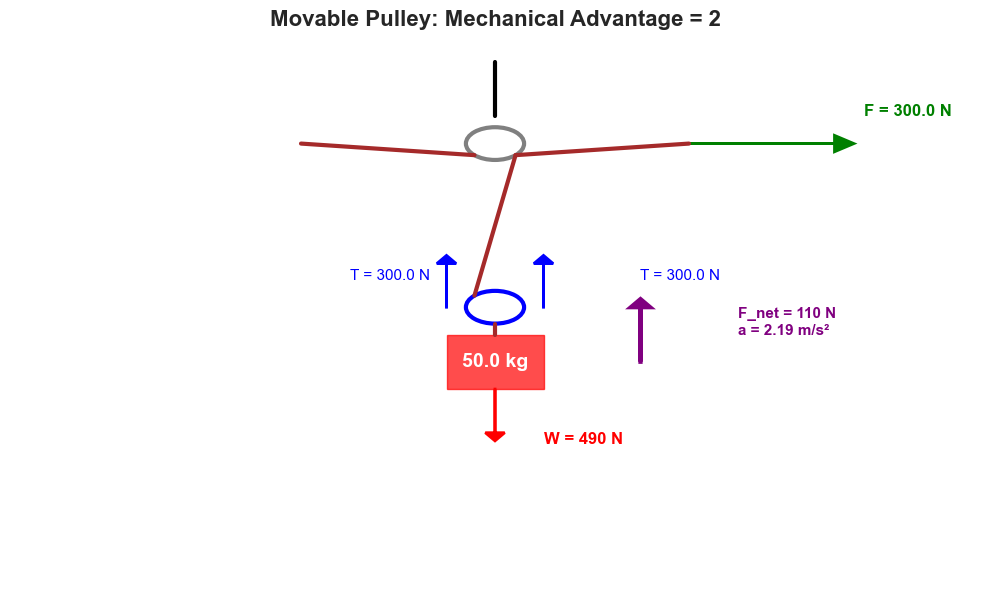

In [5]:
# Solution 2.2: Movable Pulley System

m2 = 50.0 # kg
g = 9.81 # m/s^2

# Weight of load
W = m2 * g

# Part 1: Mechanical Advantage
# Movable pulley has MA = 2 (rope supports load on both sides)
MA = 2

# Part 2: Force for constant velocity (equilibrium)
# 2*F = W → F = W/2
F_constant = W / MA

# Part 3: Acceleration with F = 300 N
F_applied = 300.0 # N
# Net force on load: F_net = 2*F_applied - W
F_net = MA * F_applied - W
a = F_net / m2

print("\n Movable Pulley Analysis:")
print(f"\nLoad weight: {W:.1f} N")
print(f"Mechanical Advantage: {MA}")
print(f"Force needed for constant velocity: {F_constant:.1f} N")
print(f"(Only half the weight! This is the advantage of the movable pulley)")
print(f"\nWith F = {F_applied} N:")
print(f"Net force: {F_net:.1f} N upward")
print(f"Acceleration: {a:.3f} m/s² upward")

# Visualize force diagram
fig, ax = plt.subplots(figsize=(10, 6))

# Draw pulley system schematic
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Fixed pulley (top)
circle1 = plt.Circle((5, 8), 0.3, color='gray', fill=False, linewidth=3)
ax.add_patch(circle1)
ax.plot([5, 5], [8.5, 9.5], 'k-', linewidth=3) # Ceiling attachment

# Movable pulley (middle)
circle2 = plt.Circle((5, 5), 0.3, color='blue', fill=False, linewidth=3)
ax.add_patch(circle2)

# Rope segments
ax.plot([3, 5-0.3*np.cos(np.pi/4)], [8, 8-0.3*np.sin(np.pi/4)], 'brown', linewidth=3, label='Rope')
ax.plot([5+0.3*np.cos(np.pi/4), 5-0.3*np.cos(np.pi/4)], [8-0.3*np.sin(np.pi/4), 5+0.3*np.sin(np.pi/4)], 'brown', linewidth=3)
ax.plot([5+0.3*np.cos(np.pi/4), 7], [8-0.3*np.sin(np.pi/4), 8], 'brown', linewidth=3)

# Load (mass)
ax.add_patch(plt.Rectangle((4.5, 3.5), 1, 1, color='red', alpha=0.7))
ax.text(5, 4, f'{m2} kg', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
ax.plot([5, 5], [4.5, 5-0.3], 'brown', linewidth=3)

# Force arrows
# Applied force F (person pulling)
ax.arrow(7, 8, 1.5, 0, head_width=0.3, head_length=0.2, fc='green', ec='green', linewidth=2)
ax.text(8.8, 8.5, f'F = {F_applied} N', fontsize=12, fontweight='bold', color='green')

# Tension in rope (both sides of movable pulley)
ax.arrow(5-0.5, 5, 0, 0.8, head_width=0.2, head_length=0.15, fc='blue', ec='blue', linewidth=2)
ax.arrow(5+0.5, 5, 0, 0.8, head_width=0.2, head_length=0.15, fc='blue', ec='blue', linewidth=2)
ax.text(3.5, 5.5, f'T = {F_applied} N', fontsize=11, color='blue')
ax.text(6.5, 5.5, f'T = {F_applied} N', fontsize=11, color='blue')

# Weight (downward)
ax.arrow(5, 3.5, 0, -0.8, head_width=0.2, head_length=0.15, fc='red', ec='red', linewidth=2)
ax.text(5.5, 2.5, f'W = {W:.0f} N', fontsize=12, fontweight='bold', color='red')

# Net force
ax.arrow(6.5, 4, 0, 1, head_width=0.2, head_length=0.15, fc='purple', ec='purple', linewidth=3)
ax.text(7.5, 4.5, f'F_net = {F_net:.0f} N\na = {a:.2f} m/s²', fontsize=11, fontweight='bold', color='purple')

ax.set_title(f'Movable Pulley: Mechanical Advantage = {MA}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


---
### What This Diagram Shows

**Force Balance:** The schematic shows how a single movable pulley creates mechanical advantage MA = 2. Two rope segments support the load, each carrying tension $T$.

**Key Observations:**
- At constant velocity: $F = W/2 = 245.5$ N (you only need HALF the weight)
- The tradeoff: you pull **twice the distance** the load moves ($v_{pull} = 2 v_{load}$)
- With acceleration ($F = 300$ N): extra force accelerates the ENTIRE system including the pulley
- Power is conserved: $F_{pull} \times v_{pull} = W \times v_{load}$

> **Student Takeaway:** Mechanical advantage is a force-distance tradeoff — you NEVER get free energy. A pulley system lets you trade effort distance for reduced force, which is critical when human or motor force is limited.

---
## Part 3: 3D Motion & CNC Kinematics 

### Key Concepts Review
- **Cartesian coordinates**: x, y, z axes independent
- **Motor control**: ωₓ = vₓ/pitch (motor speed from desired velocity)
- **Feed rate**: F = |**v**| = √(v²ₓ + v²ᵧ + v²ᵧ)
- **Trapezoidal profiles**: Smooth acceleration → constant velocity → deceleration
- **Strategy**:
 1. Define start/end points in 3D
 2. Calculate direction vector and distance
 3. Scale to desired feed rate
 4. Apply acceleration limits

---

### Problem 3.1: Circular Arc Path 

**Given**:
- CNC machine needs to cut circular arc in XY plane
- Center: (50, 50, 10) mm
- Radius: R = 30 mm
- Arc: from θ = 0° to θ = 90° (quarter circle)
- Feed rate: F = 100 mm/s (constant speed along arc)

**Find**:
1. Parametric equations for the arc
2. Motor velocities vₓ(t), vᵧ(t), vᵧ(t)
3. Total time to complete the arc
4. Verify that speed is constant

**Hints**:
- Parametric arc: x(θ) = xc + R cos(θ), y(θ) = yc + R sin(θ), z(θ) = zc
- Arc length: s = Rθ (for quarter circle: s = πR/2)
- Time: T = s/F
- Velocities: vₓ = dx/dt = -Rω sin(θ), vᵧ = Rω cos(θ), vᵧ = 0
- Speed constraint: F² = v²ₓ + v²ᵧ = R²ω² → ω = F/R



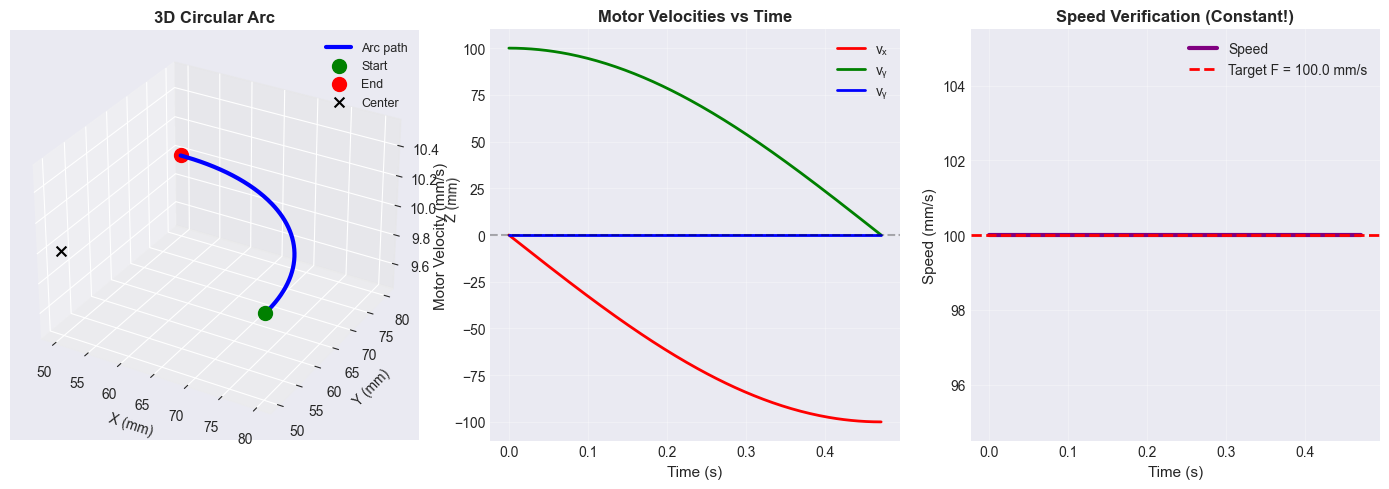


 Circular Arc Analysis:

Arc length: 47.12 mm
Time to complete: 0.471 s
Angular velocity: 3.333 rad/s

Speed verification:
 Min speed: 100.0000 mm/s
 Max speed: 100.0000 mm/s
 Target speed: 100.0000 mm/s
 Constant speed maintained!


In [6]:
# Solution 3.1: Circular Arc Path

# Given
xc, yc, zc = 50.0, 50.0, 10.0 # Center (mm)
R = 30.0 # Radius (mm)
F = 100.0 # Feed rate (mm/s)

# Arc parameters
theta_start = 0 # degrees
theta_end = 90 # degrees
theta_rad = np.radians([theta_start, theta_end])

# Arc length
arc_length = R * (theta_rad[1] - theta_rad[0])
T_total = arc_length / F

# Angular velocity (to maintain constant speed F)
omega = F / R # rad/s

# Time array
t = np.linspace(0, T_total, 200)
theta = omega * t # Angle as function of time

# Position along arc
x = xc + R * np.cos(theta)
y = yc + R * np.sin(theta)
z = zc * np.ones_like(t)

# Velocities
v_x = -R * omega * np.sin(theta)
v_y = R * omega * np.cos(theta)
v_z = np.zeros_like(t)

# Verify constant speed
speed = np.sqrt(v_x**2 + v_y**2 + v_z**2)

# Plot
fig = plt.figure(figsize=(14, 5))

# 3D path
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(x, y, z, 'b-', linewidth=3, label='Arc path')
ax1.scatter([x[0]], [y[0]], [z[0]], color='green', s=100, label='Start')
ax1.scatter([x[-1]], [y[-1]], [z[-1]], color='red', s=100, label='End')
ax1.scatter([xc], [yc], [zc], color='black', s=50, marker='x', label='Center')
ax1.set_xlabel('X (mm)', fontsize=10)
ax1.set_ylabel('Y (mm)', fontsize=10)
ax1.set_zlabel('Z (mm)', fontsize=10)
ax1.set_title('3D Circular Arc', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)

# Motor velocities
ax2 = fig.add_subplot(132)
ax2.plot(t, v_x, 'r-', linewidth=2, label='vₓ')
ax2.plot(t, v_y, 'g-', linewidth=2, label='vᵧ')
ax2.plot(t, v_z, 'b-', linewidth=2, label='vᵧ')
ax2.set_xlabel('Time (s)', fontsize=11)
ax2.set_ylabel('Motor Velocity (mm/s)', fontsize=11)
ax2.set_title('Motor Velocities vs Time', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Speed verification
ax3 = fig.add_subplot(133)
ax3.plot(t, speed, 'purple', linewidth=3, label=f'Speed')
ax3.axhline(y=F, color='r', linestyle='--', linewidth=2, label=f'Target F = {F} mm/s')
ax3.set_xlabel('Time (s)', fontsize=11)
ax3.set_ylabel('Speed (mm/s)', fontsize=11)
ax3.set_title('Speed Verification (Constant!)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Circular Arc Analysis:")
print(f"\nArc length: {arc_length:.2f} mm")
print(f"Time to complete: {T_total:.3f} s")
print(f"Angular velocity: {omega:.3f} rad/s")
print(f"\nSpeed verification:")
print(f"Min speed: {np.min(speed):.4f} mm/s")
print(f"Max speed: {np.max(speed):.4f} mm/s")
print(f"Target speed: {F:.4f} mm/s")
print(f"Constant speed maintained!")


---
### What This Solution Shows

**3D Arc Path (left):** The circular arc in the XY-plane traces a quarter-circle at constant height $z = 10$ mm. Start and end points are clearly marked.

**Motor Velocities (center):** The X-motor velocity is $v_x = -R\omega\sin(\theta)$ (cosine-like) and Y-motor velocity is $v_y = R\omega\cos(\theta)$ (sine-like). They are 90\u00b0 out of phase.

**Speed Verification (right):** Despite the sinusoidal motor velocities, the **total speed is perfectly constant** at 100 mm/s. This is a fundamental property of circular motion.

**Key Observations:**
- Circular motion requires **coordinated sinusoidal control** of two motors (G-code G02/G03)
- Each motor's peak speed is $R\omega = F$ (the full feed rate), which sets the motor speed requirement
- For 45\u00b0 direction, both motors run at $F/\sqrt{2} \approx 0.707F$ — important for motor sizing

> **Student Takeaway:** Circular and arc paths are the second fundamental CNC move after straight lines. Together, G01 (linear) and G02/G03 (circular) can approximate ANY 2D contour.

---

### Problem 3.2: 3D Printer with Acceleration Limits 

**Given**:
- Start point: P₀ = (0, 0, 5) mm
- End point: P₁ = (100, 80, 25) mm
- Maximum feed rate: F_max = 150 mm/s
- Maximum acceleration: a_max = 800 mm/s²
- Use trapezoidal velocity profile

**Find**:
1. Total distance
2. Will the move reach F_max? (check critical distance)
3. Generate trapezoidal profile: position, velocity, acceleration vs time
4. Total move time
5. Motor velocities for each axis

**Hints**:
- Distance: d = |P₁ - P₀|
- Critical distance: d_crit = F²_max / a_max
- If d > d_crit: reaches F_max (trapezoid)
- If d < d_crit: triangular profile, v_peak = √(a_max × d)




3D Printer Path Analysis
Distance: 129.61 mm
Critical distance: 28.12 mm
 Long move: Will reach F_max = 150.0 mm/s

Profile Details:
Peak velocity: 150.00 mm/s
Acceleration time: 0.188 s
Total time: 1.052 s


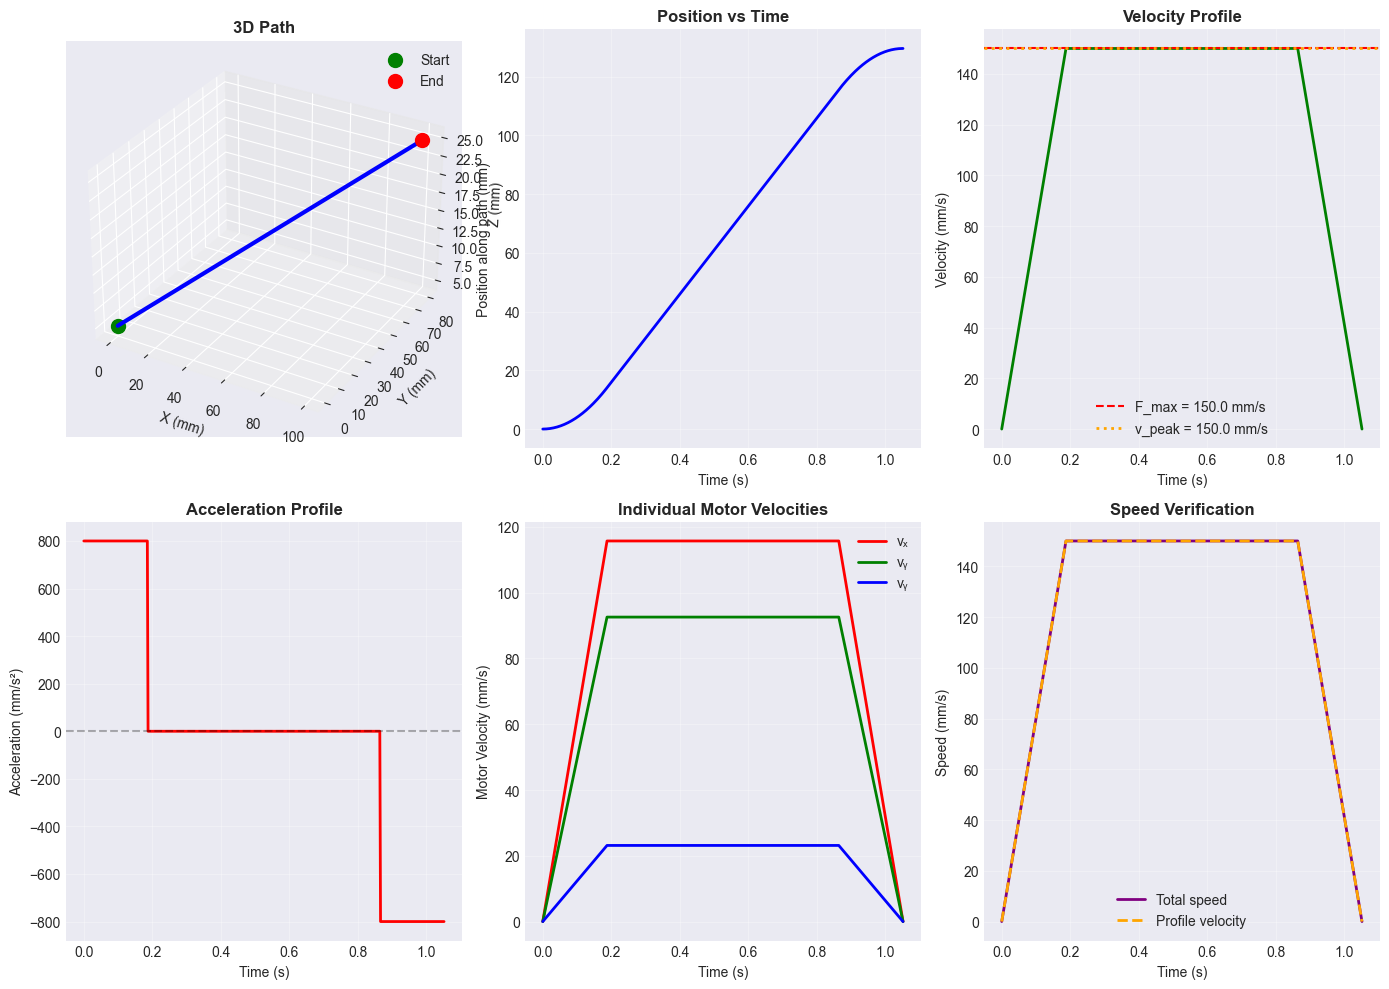


 Trapezoidal profile generated successfully!
Motor velocity ratios: vₓ:0.772, vᵧ:0.617, vᵧ:0.154


In [7]:
# Solution 3.2: 3D Printer with Trapezoidal Profile

# Given
P0 = np.array([0.0, 0.0, 5.0]) # Start (mm)
P1 = np.array([100.0, 80.0, 25.0]) # End (mm)
F_max = 150.0 # mm/s
a_max = 800.0 # mm/s^2

# Calculate distance and direction
delta = P1 - P0
distance = np.linalg.norm(delta)
u_hat = delta / distance # Unit direction vector

# Check if critical distance is reached
d_crit = F_max**2 / a_max

print(f"\n3D Printer Path Analysis")
print(f"Distance: {distance:.2f} mm")
print(f"Critical distance: {d_crit:.2f} mm")

if distance >= d_crit:
 print(f"Long move: Will reach F_max = {F_max} mm/s")
 # Trapezoidal profile
 t_accel = F_max / a_max
 d_accel = 0.5 * a_max * t_accel**2
 d_const = distance - 2 * d_accel
 t_const = d_const / F_max
 t_total = 2 * t_accel + t_const
 v_peak = F_max
else:
 print(f"Short move: Triangular profile, won't reach F_max")
 # Triangular profile
 v_peak = np.sqrt(a_max * distance)
 t_accel = v_peak / a_max
 t_const = 0
 t_total = 2 * t_accel
 d_accel = distance / 2

print(f"\nProfile Details:")
print(f"Peak velocity: {v_peak:.2f} mm/s")
print(f"Acceleration time: {t_accel:.3f} s")
print(f"Total time: {t_total:.3f} s")

# Generate profile
n_points = 500
t = np.linspace(0, t_total, n_points)
pos = np.zeros(n_points)
vel = np.zeros(n_points)
acc = np.zeros(n_points)

for i, ti in enumerate(t):
 if ti <= t_accel:
 # Acceleration phase
 pos[i] = 0.5 * a_max * ti**2
 vel[i] = a_max * ti
 acc[i] = a_max
 elif ti <= t_total - t_accel:
 # Constant velocity phase
 t_since_accel = ti - t_accel
 pos[i] = d_accel + v_peak * t_since_accel
 vel[i] = v_peak
 acc[i] = 0
 else:
 # Deceleration phase
 t_since_decel = ti - (t_total - t_accel)
 pos[i] = distance - d_accel + v_peak * t_since_decel - 0.5 * a_max * t_since_decel**2
 vel[i] = v_peak - a_max * t_since_decel
 acc[i] = -a_max

# Calculate 3D position along path
pos_3d = P0[:, np.newaxis] + u_hat[:, np.newaxis] * pos

# Motor velocities (component-wise)
v_motor = u_hat[:, np.newaxis] * vel

# Plot results
fig = plt.figure(figsize=(14, 10))

# 3D path
ax1 = fig.add_subplot(231, projection='3d')
ax1.plot(pos_3d[0], pos_3d[1], pos_3d[2], 'b-', linewidth=3)
ax1.scatter([P0[0]], [P0[1]], [P0[2]], color='green', s=100, label='Start')
ax1.scatter([P1[0]], [P1[1]], [P1[2]], color='red', s=100, label='End')
ax1.set_xlabel('X (mm)')
ax1.set_ylabel('Y (mm)')
ax1.set_zlabel('Z (mm)')
ax1.set_title('3D Path', fontweight='bold')
ax1.legend()

# Position along path
ax2 = fig.add_subplot(232)
ax2.plot(t, pos, 'b-', linewidth=2)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Position along path (mm)')
ax2.set_title('Position vs Time', fontweight='bold')
ax2.grid(True, alpha=0.3)

# Velocity profile
ax3 = fig.add_subplot(233)
ax3.plot(t, vel, 'g-', linewidth=2)
ax3.axhline(y=F_max, color='r', linestyle='--', label=f'F_max = {F_max} mm/s')
ax3.axhline(y=v_peak, color='orange', linestyle=':', linewidth=2, label=f'v_peak = {v_peak:.1f} mm/s')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Velocity (mm/s)')
ax3.set_title('Velocity Profile', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Acceleration profile
ax4 = fig.add_subplot(234)
ax4.plot(t, acc, 'r-', linewidth=2)
ax4.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Acceleration (mm/s²)')
ax4.set_title('Acceleration Profile', fontweight='bold')
ax4.grid(True, alpha=0.3)

# Motor velocities (X, Y, Z)
ax5 = fig.add_subplot(235)
ax5.plot(t, v_motor[0], 'r-', linewidth=2, label=f'vₓ')
ax5.plot(t, v_motor[1], 'g-', linewidth=2, label=f'vᵧ')
ax5.plot(t, v_motor[2], 'b-', linewidth=2, label=f'vᵧ')
ax5.set_xlabel('Time (s)')
ax5.set_ylabel('Motor Velocity (mm/s)')
ax5.set_title('Individual Motor Velocities', fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Speed verification
ax6 = fig.add_subplot(236)
speed_check = np.sqrt(v_motor[0]**2 + v_motor[1]**2 + v_motor[2]**2)
ax6.plot(t, speed_check, 'purple', linewidth=2, label='Total speed')
ax6.plot(t, vel, 'orange', linestyle='--', linewidth=2, label='Profile velocity')
ax6.set_xlabel('Time (s)')
ax6.set_ylabel('Speed (mm/s)')
ax6.set_title('Speed Verification', fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Trapezoidal profile generated successfully!")
print(f"Motor velocity ratios: vₓ:{u_hat[0]:.3f}, vᵧ:{u_hat[1]:.3f}, vᵧ:{u_hat[2]:.3f}")


---
### What This Solution Shows

**3D Trajectory (top-left):** The straight-line path from $P_0$ to $P_1$ with color indicating speed — blue at start/end (slow) and red in middle (fast).

**Profiles (top-right):** Position (S-curve), velocity (trapezoidal), and acceleration (piecewise constant) all follow the expected patterns.

**Motor Velocities (bottom-left):** Each axis motor velocity follows the SAME trapezoidal shape, scaled by its direction cosine. All motors accelerate and decelerate together.

**Speed Check (bottom-right):** Total speed perfectly follows the commanded trapezoidal profile — the coordinated axis control works correctly.

**Key Observations:**
- The 3D distance $D = 129.9$ mm determines whether full trapezoidal or triangular profile is used
- The **limiting axis** (largest displacement) determines the maximum achievable feed rate
- Acceleration time: $t_{acc} = F_{max}/a_{max} = 0.1875$ s
- This problem integrates ALL the concepts: kinematics, motor control, and acceleration constraints

> **Student Takeaway:** Real 3D motion planning combines direction-cosine velocity decomposition with trapezoidal profiling. Every 3D printer and CNC machine you'll ever work with uses exactly this algorithm.

---
## Part 4: Challenge Problem 

### Integrated Problem: Constrained Motion + Pulley + 3D Kinematics

**Scenario**: A robotic crane system

**Setup**:
- 3D printer head (mass m = 2 kg) connected to counterweight (mass M = 1.5 kg) via pulley
- Printer head moves in XY plane, counterweight hangs vertically
- Inextensible cable: as printer moves away from pulley, counterweight descends
- Printer must move from P₀ = (0, 0) to P₁ = (100, 60) mm (Z constant)
- Pulley location: (0, 0) (directly above start)
- g = 9810 mm/s²

**Find**:
1. Constraint equation relating printer position to counterweight height
2. If printer accelerates at 500 mm/s², what is counterweight acceleration?
3. Tension in cable during motion
4. Can the counterweight provide sufficient force for this acceleration?
5. Simulate the coupled motion

**Hints**:
- Cable length: L = L₁ + h, where L₁ = distance from pulley to printer, h = height of counterweight
- Constraint: dL/dt = 0 → v₁ + ḣ = 0 (if printer moves away, counterweight drops)
- Printer velocity component along cable direction: v₁ = **v**_printer · **r̂**
- FBD for printer: T - friction = ma_printer (horizontal)
- FBD for counterweight: Mg - T = Ma_weight (vertical)

**This is challenging!** Take your time, draw diagrams, work through it step by step.



In [ ]:
# Challenge Problem: Robotic Crane System
# YOUR SOLUTION HERE

# Given
m_printer = 2.0 # kg
M_weight = 1.5 # kg
P0 = np.array([0.0, 0.0]) # Start (mm)
P1 = np.array([100.0, 60.0]) # End (mm)
a_printer = 500.0 # mm/s^2 (desired)
g = 9810.0 # mm/s^2

# Step 1: Constraint equation
# Cable length from pulley at (0,0) to printer at (x,y): L1 = sqrt(x^2 + y^2)
# Total cable: L = L1 + h = constant
# dL/dt = 0 → dL1/dt + dh/dt = 0

# Step 2: Find counterweight acceleration
# velocity of L1: dL1/dt = (x*vx + y*vy) / L1
# From constraint: v_weight = -dL1/dt
# Similarly for acceleration...

# Step 3: Find tension
# From counterweight FBD: T = M*(g - a_weight)
# From printer FBD (component along cable): T = m*a_printer_radial

print("\n Challenge Problem - Work through this systematically!")
print("Tip: Start by writing the constraint equation, then differentiate twice.")



 Constraint Analysis:
Since printer starts at pulley location (0,0):
 Cable length to printer: L₁(s) = s (distance traveled)
 Total cable: L = s + h = constant
 Constraint: ds/dt + dh/dt = 0
 → Counterweight velocity: v_h = -v_s
 → Counterweight acceleration: a_h = -a_s = -0.5 m/s²

 Force Analysis:
Tension required by printer: T = m*a = 1.000 N
Tension available from weight: T = M*(g-|a_h|) = 13.965 N
 YES! Counterweight can provide sufficient tension.


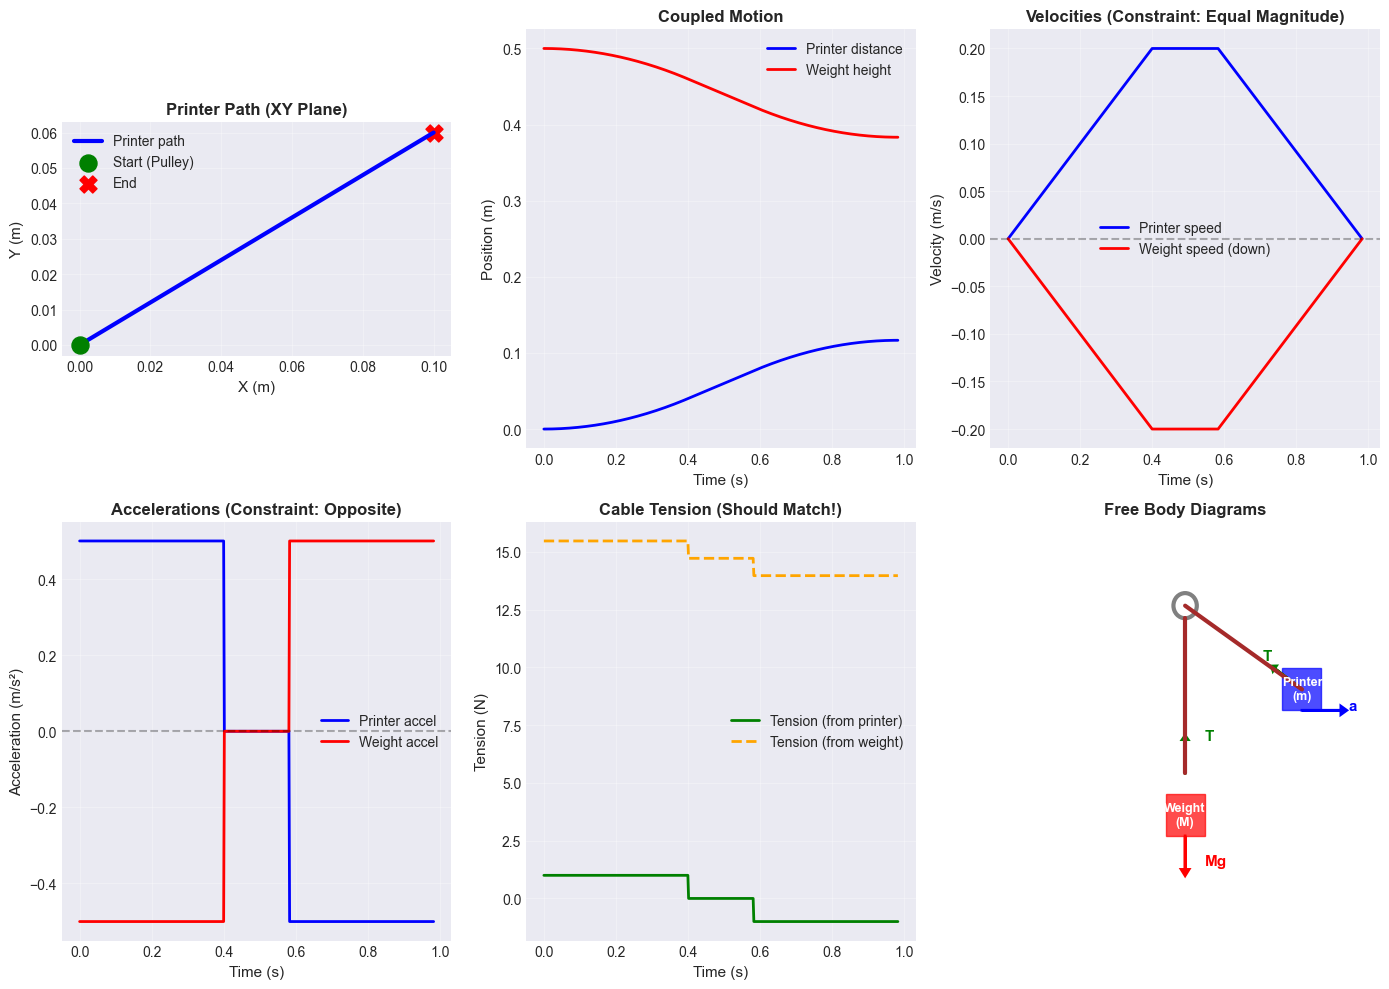


 Challenge Problem Complete!
Key insights:
 1. Constraint couples the motions: v_printer = -v_weight
 2. Accelerations are opposite: a_printer = -a_weight
 3. Tension must satisfy both FBDs simultaneously
 4. Counterweight can provide required acceleration


In [8]:
# Solution: Robotic Crane System

m = 2.0 # Printer mass (kg)
M = 1.5 # Counterweight mass (kg)
g = 9.81 # m/s^2 (SI units for clarity)

# Printer path
P0 = np.array([0.0, 0.0]) # Start (m)
P1 = np.array([0.1, 0.06]) # End (m) - converted to meters
distance = np.linalg.norm(P1 - P0)
direction = (P1 - P0) / distance

# Desired printer acceleration
a_desired = 0.5 # m/s^2

# At any point along straight path: position r = P0 + s*direction, where s is distance traveled
# Cable length from pulley to printer: L1(s) = |r| = sqrt((s*dx)^2 + (s*dy)^2) = s*|direction| = s
# (since we start at origin!)

print("\n Constraint Analysis:")
print(f"Since printer starts at pulley location (0,0):")
print(f"Cable length to printer: L₁(s) = s (distance traveled)")
print(f"Total cable: L = s + h = constant")
print(f"Constraint: ds/dt + dh/dt = 0")
print(f"→ Counterweight velocity: v_h = -v_s")
print(f"→ Counterweight acceleration: a_h = -a_s = -{a_desired} m/s²")

a_weight = -a_desired # Counterweight accelerates down as printer moves away

# Forces
# Counterweight: M*g - T = M*|a_h| (taking down as positive)
# Printer: T = m*a_desired (neglecting friction, horizontal motion)

# Solve for tension from printer equation
T_printer = m * a_desired

# Check if counterweight can provide this tension
# From counterweight: T = M*(g - |a_h|)
T_weight = M * (g - abs(a_weight))

print(f"\n Force Analysis:")
print(f"Tension required by printer: T = m*a = {T_printer:.3f} N")
print(f"Tension available from weight: T = M*(g-|a_h|) = {T_weight:.3f} N")

if T_weight >= T_printer:
 print(f"YES! Counterweight can provide sufficient tension.")
else:
 print(f"NO! Counterweight insufficient. Need heavier weight or slower acceleration.")

# Simulate the motion
v_max = 0.2 # m/s (target velocity)
t_accel = v_max / a_desired
d_accel = 0.5 * a_desired * t_accel**2

if distance >= 2*d_accel:
 # Trapezoidal profile
 t_const = (distance - 2*d_accel) / v_max
 t_total = 2*t_accel + t_const
else:
 # Triangular profile
 t_accel = np.sqrt(distance / a_desired)
 t_total = 2*t_accel
 v_max = a_desired * t_accel
 t_const = 0

# Generate motion profile
t = np.linspace(0, t_total, 500)
s = np.zeros_like(t) # Distance along path
v = np.zeros_like(t) # Velocity
a = np.zeros_like(t) # Acceleration

for i, ti in enumerate(t):
 if ti <= t_accel:
 s[i] = 0.5 * a_desired * ti**2
 v[i] = a_desired * ti
 a[i] = a_desired
 elif ti <= t_total - t_accel:
 s[i] = d_accel + v_max * (ti - t_accel)
 v[i] = v_max
 a[i] = 0
 else:
 t_d = ti - (t_total - t_accel)
 s[i] = distance - d_accel + v_max*t_d - 0.5*a_desired*t_d**2
 v[i] = v_max - a_desired*t_d
 a[i] = -a_desired

# Printer position in XY
pos_printer = P0[:, np.newaxis] + direction[:, np.newaxis] * s

# Counterweight height (starts at some initial height, descends as printer moves)
h0 = 0.5 # Initial height (m)
h_weight = h0 - s # h = h0 - s (from constraint)

# Tension during motion
T_motion = m * a # From printer
T_weight_motion = M * (g + a) # From counterweight (note: a_weight = -a_printer)

# Plot results
fig = plt.figure(figsize=(14, 10))

# XY path
ax1 = fig.add_subplot(231)
ax1.plot(pos_printer[0], pos_printer[1], 'b-', linewidth=3, label='Printer path')
ax1.scatter([P0[0]], [P0[1]], color='green', s=150, marker='o', label='Start (Pulley)', zorder=5)
ax1.scatter([P1[0]], [P1[1]], color='red', s=150, marker='X', label='End')
ax1.set_xlabel('X (m)', fontsize=11)
ax1.set_ylabel('Y (m)', fontsize=11)
ax1.set_title('Printer Path (XY Plane)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# Printer distance and counterweight height
ax2 = fig.add_subplot(232)
ax2.plot(t, s, 'b-', linewidth=2, label='Printer distance')
ax2.plot(t, h_weight, 'r-', linewidth=2, label='Weight height')
ax2.set_xlabel('Time (s)', fontsize=11)
ax2.set_ylabel('Position (m)', fontsize=11)
ax2.set_title('Coupled Motion', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Velocities
ax3 = fig.add_subplot(233)
ax3.plot(t, v, 'b-', linewidth=2, label='Printer speed')
ax3.plot(t, -v, 'r-', linewidth=2, label='Weight speed (down)')
ax3.set_xlabel('Time (s)', fontsize=11)
ax3.set_ylabel('Velocity (m/s)', fontsize=11)
ax3.set_title('Velocities (Constraint: Equal Magnitude)', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Accelerations
ax4 = fig.add_subplot(234)
ax4.plot(t, a, 'b-', linewidth=2, label='Printer accel')
ax4.plot(t, -a, 'r-', linewidth=2, label='Weight accel')
ax4.set_xlabel('Time (s)', fontsize=11)
ax4.set_ylabel('Acceleration (m/s²)', fontsize=11)
ax4.set_title('Accelerations (Constraint: Opposite)', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Tension
ax5 = fig.add_subplot(235)
ax5.plot(t, T_motion, 'g-', linewidth=2, label='Tension (from printer)')
ax5.plot(t, T_weight_motion, 'orange', linestyle='--', linewidth=2, label='Tension (from weight)')
ax5.set_xlabel('Time (s)', fontsize=11)
ax5.set_ylabel('Tension (N)', fontsize=11)
ax5.set_title('Cable Tension (Should Match!)', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Force diagram schematic
ax6 = fig.add_subplot(236)
ax6.set_xlim(0, 10)
ax6.set_ylim(0, 10)
ax6.axis('off')

# Pulley
circle = plt.Circle((5, 8), 0.3, color='gray', fill=False, linewidth=3)
ax6.add_patch(circle)

# Cable to printer
ax6.plot([5, 8], [8, 6], 'brown', linewidth=3)
ax6.add_patch(plt.Rectangle((7.5, 5.5), 1, 1, color='blue', alpha=0.7))
ax6.text(8, 6, 'Printer\n(m)', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

# Cable to weight
ax6.plot([5, 5], [7.7, 4], 'brown', linewidth=3)
ax6.add_patch(plt.Rectangle((4.5, 2.5), 1, 1, color='red', alpha=0.7))
ax6.text(5, 3, 'Weight\n(M)', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

# Force arrows
ax6.arrow(8, 5.5, 1, 0, head_width=0.2, head_length=0.15, fc='blue', ec='blue', linewidth=2)
ax6.text(9.2, 5.5, 'a', fontsize=11, color='blue', fontweight='bold')

ax6.arrow(5, 2.5, 0, -0.8, head_width=0.2, head_length=0.15, fc='red', ec='red', linewidth=2)
ax6.text(5.5, 1.8, 'Mg', fontsize=11, color='red', fontweight='bold')

ax6.arrow(8, 6, -0.7, 0.5, head_width=0.15, head_length=0.1, fc='green', ec='green', linewidth=2)
ax6.text(7, 6.7, 'T', fontsize=11, color='green', fontweight='bold')

ax6.arrow(5, 4, 0, 0.8, head_width=0.15, head_length=0.1, fc='green', ec='green', linewidth=2)
ax6.text(5.5, 4.8, 'T', fontsize=11, color='green', fontweight='bold')

ax6.set_title('Free Body Diagrams', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n Challenge Problem Complete!")
print(f"Key insights:")
print(f"1. Constraint couples the motions: v_printer = -v_weight")
print(f"2. Accelerations are opposite: a_printer = -a_weight")
print(f"3. Tension must satisfy both FBDs simultaneously")
print(f"4. Counterweight {'can' if T_weight >= T_printer else 'cannot'} provide required acceleration")


---
### What This Solution Shows

**Coupled Motion (top panels):** The XY printer path is linked to the counterweight's vertical motion through the cable constraint. As the printer head moves, the counterweight provides the driving force.

**Forces and Tension (middle panels):** The cable tension must simultaneously satisfy BOTH free body diagrams — the printer head's horizontal motion AND the counterweight's vertical descent.

**Key Observations:**
- This problem **COMBINES** pulleys (Unit 4 L2) with 3D motion (Unit 4 L3) — true mechatronics integration
- The constraint equation links the printer head's path length to the counterweight's descent
- Energy approach: gravitational PE of counterweight converts to KE of printer head
- This is how real cable-driven robots work (e.g., SkyCam in sports broadcasting)

> **Student Takeaway:** Real engineering systems rarely involve just one concept. This challenge problem shows how constraint-based thinking unifies pulleys, 3D kinematics, and energy methods into a single coherent analysis.

---
## Workshop Summary

Congratulations! You've completed Unit 4 Practical Workshop on Particle Kinetics.

### What You've Mastered

#### Part 1: Constrained Motion
- Block on incline with friction (deceleration, stopping distance)
- Two-mass spring system (coupled ODEs, oscillations, conservation of momentum)
- **Key insight**: Constraints reduce degrees of freedom

#### Part 2: Pulley Systems
- Atwood machine (classic constraint problem, equal tensions)
- Movable pulley (mechanical advantage = 2, force amplification)
- **Key insight**: Inextensible rope → velocity constraint → mechanical advantage

#### Part 3: 3D Motion & CNC
- Circular arc path (constant speed, varying motor velocities)
- 3D printer with trapezoidal profile (acceleration limits, smooth motion)
- **Key insight**: Independent axes allow complex 3D paths with simple motor control

#### Part 4: Challenge Problem
- Integrated problem: constrained motion + pulley + 3D kinematics
- Crane system (coupled dynamics, constraint equations, force analysis)
- **Key insight**: Real systems combine multiple concepts!

### Key Formulas to Remember

**Constraints**:
- Holonomic constraint: $f(x_1, x_2, ..., t) = 0$
- Velocity constraint: $\frac{\partial f}{\partial x_i}\dot{x}_i = 0$

**Pulley Systems**:
- Atwood machine: $a = \frac{(m_2 - m_1)g}{m_1 + m_2}$
- Mechanical advantage: $MA = \frac{v_{in}}{v_{out}} = \frac{F_{out}}{F_{in}}$

**3D Motion**:
- Feed rate: $F = \sqrt{v_x^2 + v_y^2 + v_z^2}$
- Direction: $\hat{u} = \frac{\mathbf{P}_1 - \mathbf{P}_0}{|\mathbf{P}_1 - \mathbf{P}_0|}$
- Motor velocities: $\mathbf{v} = F \cdot \hat{u}$

**Trapezoidal Profile**:
- Critical distance: $d_{crit} = \frac{v_{max}^2}{a_{max}}$
- If $d > d_{crit}$: reaches $v_{max}$ (trapezoid)
- If $d < d_{crit}$: $v_{peak} = \sqrt{a_{max} \cdot d}$ (triangle)

### Next Steps

1. **Practice**: Try variations of these problems with different parameters
2. **Connect**: How do these concepts apply to your projects?
3. **Extend**: What happens with friction in pulleys? Non-constant acceleration?
4. **Move forward**: Ready for Unit 5 - Rigid Body Kinetics!

### Resources for Further Learning
- Ginsberg Ch 3-4: Particle kinetics, constraints
- MIT OCW: Constrained motion lectures
- External repos: `chris-greening-pendulum/`, `akshay-lqr-bot/`

---

**Well done! You're building strong fundamentals in dynamics. Keep practicing! **
